<h1>Import Libraries</h1>

In [10]:
#caculations
import pandas as pd
import numpy as np

#display
from IPython.display import display

#visualistations
import seaborn as sns
import matplotlib.pyplot as plt

<h1>Load Dataset</h1>

In [6]:
df = pd.read_csv('german_credit_data.csv')

<h1>Explore data</h1>

In [34]:
display(df.head(10))

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
5,5,35,male,1,free,NaN,NaN,9055,36,education,good
6,6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment,good
7,7,35,male,3,rent,little,moderate,6948,36,car,good
8,8,61,male,1,own,rich,NaN,3059,12,radio/TV,good
9,9,28,male,3,own,little,moderate,5234,30,car,bad


In [13]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


None

In [14]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,499.500,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,35.546,11.375469,19.0,27.00,33.0,42.00,75.0
Job,1000.0,1.904,0.653614,0.0,2.00,2.0,2.00,3.0
Credit amount,1000.0,3271.258,2822.736876,250.0,1365.50,2319.5,3972.25,18424.0
Duration,1000.0,20.903,12.058814,4.0,12.00,18.0,24.00,72.0


In [56]:
display(df.nunique())

Unnamed: 0          1000
Age                   53
Sex                    2
Job                    4
Housing                3
Saving accounts        4
Checking account       3
Credit amount        921
Duration              33
Purpose                8
Risk                   2
Age_cat                4
dtype: int64

<h1>Visualisations</h1>

<h2>Count of Age, Job, Credit amount and Duration</h2>

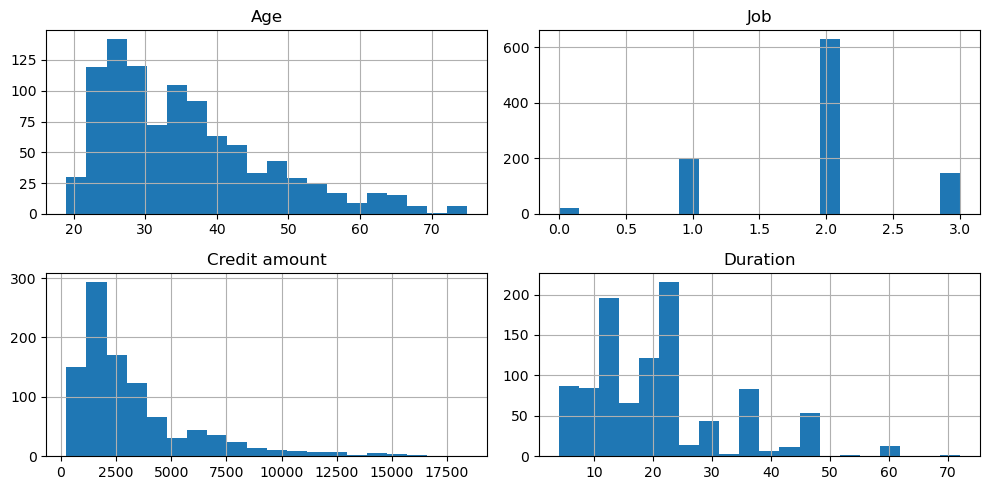

In [40]:
df[['Age', 'Job', 'Credit amount', 'Duration']].hist(bins=20, figsize = (10,5))
plt.tight_layout()
plt.show()

<b>Findings
<p>There is a trend of younger individuals having credit than older individuals.</p>
<p>There is a large amount of individuals who have 2 jobs in comparison to those with 0, 1 or 3.</p>
<p>The amount of credit individuals have tend to be on the lower side.</p>

<h2>Good vs Bad Credit Risk</h2>

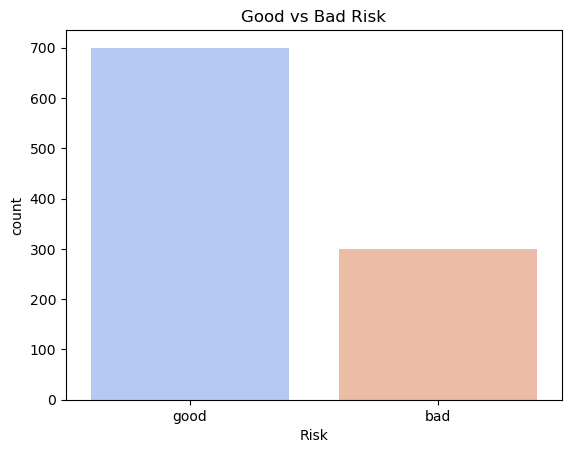

In [108]:
sns.countplot(x='Risk', data=df, hue = 'Risk', palette = 'coolwarm')
plt.title('Good vs Bad Risk')
plt.show()

<b>Findings
<p>There is a larger amount of people with good risk compared to individuals with bad risk.</p>

<h2>Boxplot - Credit amount vs Job number grouped by Gender</h2>

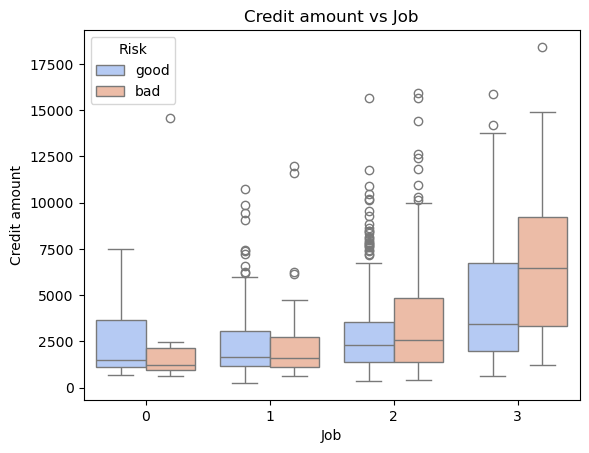

In [109]:
sns.boxplot(x='Job',y='Credit amount', data=df, hue='Risk', palette = 'coolwarm')
plt.title('Credit amount vs Job')
plt.show()

<b>Findings
<p>Individuals with 3 jobs have a higher average credit amount. There are a lot of outliers with individuals with 1 and 2 jobs. Majority of the credit amount is between R1200 and R9500.</p>
<p>Individuals with no or 1 job tend to have more good credit risk whereas individuals with 2 or more jobs tend to have more bad risk.</p>

In [73]:
#Creating age categories
interval = (18, 25, 35, 60, 120)

age_cat = ['Young', 'Student', 'Adult', 'Senior']
df["Age_cat"] = pd.cut(df.Age, interval, labels=age_cat)


good_risk = df[df['Risk'] == 'good']
bad_risk = df[df['Risk'] == 'bad']

<h2>Boxplot - Credit amount vs Age category grouped by Risk</h2>

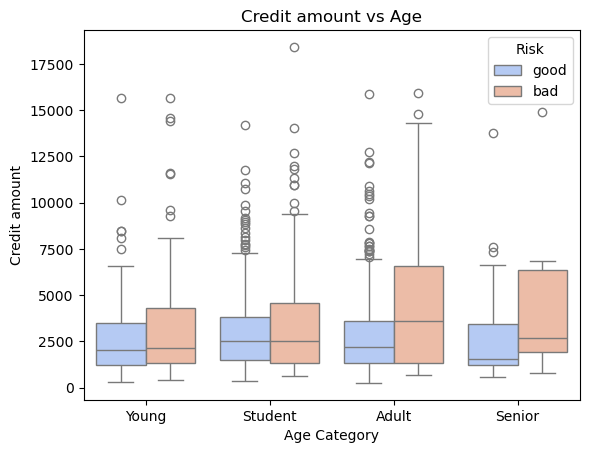

In [112]:
sns.boxplot(x='Age_cat',y='Credit amount', data=df, hue='Risk', palette = 'coolwarm')
plt.title('Credit amount vs Age')
plt.xlabel('Age Category')
plt.show()

<b>Findings
<p>There is a similar average of good risk between all ages where as older individuals tend to have bad credit risk. There are more cases of bad risk compared to good risk between all age groups</p>

<H2>Barplot - Credit amount vs Sex grouped by Risk</H2>

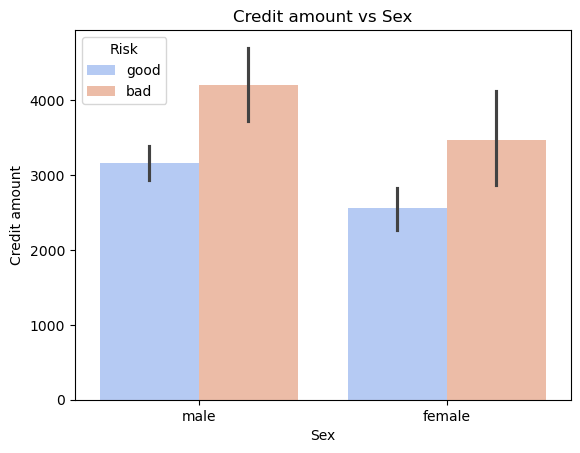

In [113]:
sns.barplot(x='Sex', y='Credit amount', data=df, hue = 'Risk', palette = 'coolwarm')
plt.title('Credit amount vs Sex')
plt.show()

<b>Findings
<p>There are more male individuals with credit with both feamle and male individuals have more bad risk than good risk.</p>

<h2>Countplot - Count of Housing</h2>

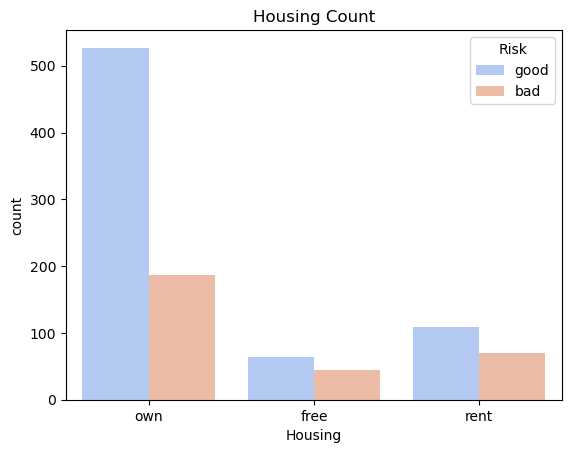

In [114]:
sns.countplot(x='Housing', data=df, hue = 'Risk', palette = 'coolwarm')
plt.title('Housing Count')
plt.show()

<b>Findings
<p>There is a larger amount of Individuals who own a house and have credit. We can also see a strong correlation between individuals owning a house and having good credit. </p>

<h2>Countplot - Count of Purpose</h2>

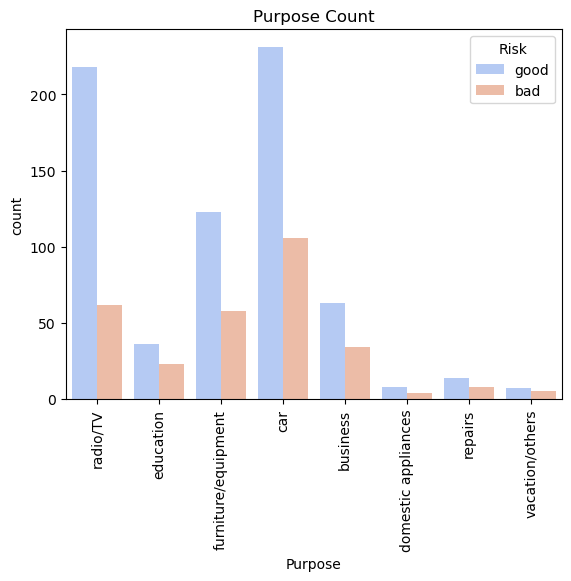

In [115]:
sns.countplot(x='Purpose', data=df, hue='Risk', palette = 'coolwarm' )
plt.xticks(rotation=90)
plt.title('Purpose Count')
plt.show()

<b>Findings
<p>There are high counts of credit for radio/TV, furniture and car purposes. There is also a large difference in there being more good risk than bad risk for purpose of credit.</p>

<h1>Overall Findings</h1>

<p>Credit is more prevalent among younger customers, most individuals have 2 incomes, and amount appears right skewed. Overall the portfolio is in good shape with ~70% of customers being good customers. There are some interesting trends within groups. Individuals with 3 jobs have the highest amounts but are more likely to be a bad risk. Individuals with 0 or 1 jobs are more inclined to be a good risk. In every age bucket there are more bad risks than good, and older customers have a disproportionately high amount of bad risk. Males are the majority of individuals, and both males and females are more likely to be a bad risk. Having owned a home is a strong positive signal in this dataset. Individuals that used the credit for radio/TVs, furniture, and cars used the highest amounts of credit, and these segments also have the largest delta between good and bad risk.</p>